Polish the object.

In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import torch
import pytorch_lightning.loggers
import rapids_singlecell as rsc
import sc_utils
import gc

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


## Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07c_1000_10-2/07c_1000_10-2.h5ad')

In [67]:
adata[adata.obs.cell_type == "Epithelial, squamous"]

View of AnnData object with n_obs × n_vars = 379 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Clean up doublets
C1QA+ clusters in plasma and ciliated cells

## Remove C1QA+ cluster from plasma & proliferating plasma cells

In [3]:
plasma = adata[adata.obs.cell_type.isin(["Plasma cells", "Proliferating plasma cells"])]

In [4]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(plasma, use_rep="X_scVI")
rsc.tl.umap(plasma, min_dist=0.3)

In [5]:
# neighbors were already computed using scVI
rsc.tl.leiden(plasma, key_added="cell_type", resolution=0.15)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


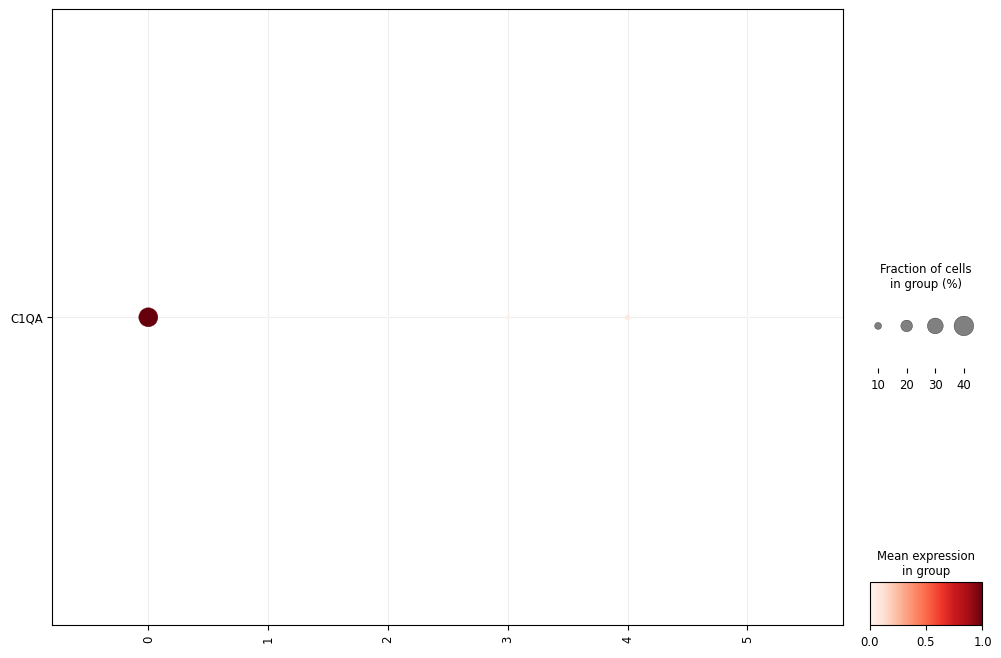

In [6]:
ax = sc.pl.dotplot(
    plasma,
    ["C1QA"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [7]:
plasma_cells = plasma.obs[plasma.obs.cell_type.isin(['0'])].index

In [8]:
plasma_df = pd.DataFrame(plasma.obs[plasma.obs.cell_type.isin(['0'])].index, columns=["Index"])

In [9]:
plasma_df.to_csv('plasma_doublets.csv', index=False)

In [10]:
del plasma

## Remove these cells from adata object

In [11]:
adata.shape

(2480619, 1000)

In [12]:
adata = adata[~adata.obs.index.isin(plasma_cells)]

In [13]:
adata.shape

(2472976, 1000)

## Save

In [ ]:
adata.write(common_data._sc_root / 'scratch/07c_1000_10-2-1.h5ad')

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / 'scratch/07c_1000_10-2-1.h5ad')

In [4]:
adata[adata.obs.cell_type == "Epithelial, squamous"]

View of AnnData object with n_obs × n_vars = 379 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Remove C1QA+ cluster from ciliated cells, secretory cells, and epithelial cells

In [3]:
epithelial = adata[adata.obs.cell_type.isin(['Ciliated cells', 'Secretory cells', 'Epithelial, squamous'])]

In [4]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(epithelial, use_rep="X_scVI")
rsc.tl.umap(epithelial, min_dist=0.3)

In [5]:
# neighbors were already computed using scVI
rsc.tl.leiden(epithelial, key_added="cell_type", resolution=0.2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


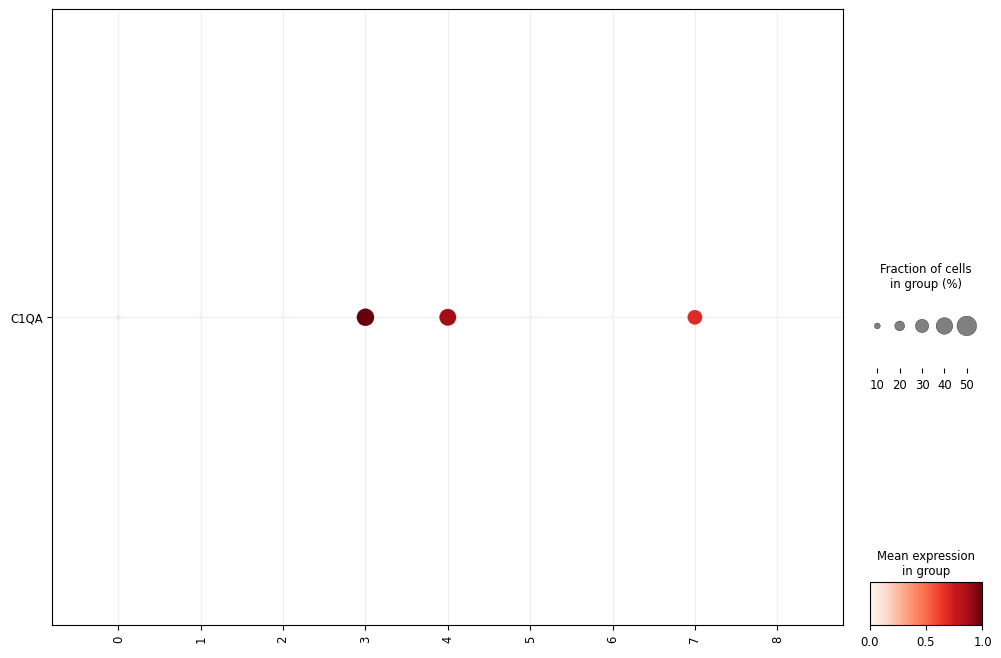

In [6]:
ax = sc.pl.dotplot(
    epithelial,
    ["C1QA"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [7]:
epithelial_cells = epithelial.obs[epithelial.obs.cell_type.isin(['3','4','7'])].index

In [8]:
del epithelial

## Remove these cells from adata object

In [9]:
adata.shape

(2472976, 1000)

In [10]:
adata = adata[~adata.obs.index.isin(epithelial_cells)]

In [11]:
adata.shape

(2467157, 1000)

## Save

In [ ]:
adata.write(common_data._sc_root / 'scratch/07c_1000_10-2-2.h5ad')

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / 'scratch/07c_1000_10-2-2.h5ad')

In [3]:
adata[adata.obs.cell_type == "Epithelial, squamous"]

View of AnnData object with n_obs × n_vars = 1 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Resolve AT1, AT2 cells, & ionocytes

In [4]:
epithelial = adata[adata.obs.cell_type.isin(['Epithelial cells'])]

In [5]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(epithelial, use_rep="X_scVI")
rsc.tl.umap(epithelial, min_dist=0.3)

In [6]:
# neighbors were already computed using scVI
rsc.tl.leiden(epithelial, key_added="cell_type", resolution=0.3)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


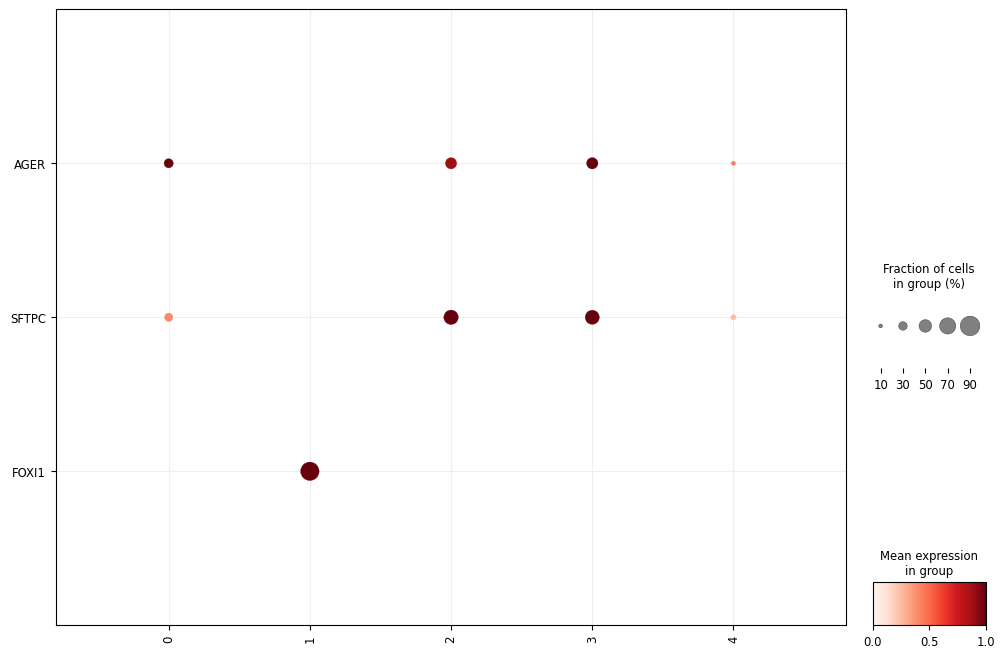

In [7]:
ax = sc.pl.dotplot(
    epithelial,
    ["AGER","SFTPC","FOXI1"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

AT1 and AT2 cannot be resolved, but ionocytes are,

In [8]:
epithelial.obs.cell_type.replace({
    "0": "Epithelial cells",
    "1": "Ionocytes",
    "2": "Epithelial cells",
    "3": "Epithelial cells",
    "4": "Epithelial cells",
}, inplace=True)

## T cells

Rename proliferating gdT cells > proliferating CD8 and gdT cells

Resolve proliferating CD4 T cells (currently named Tregs)

In [9]:
adata.obs.cell_type.replace({
    "Proliferating gdT cells": "Proliferating CD8 and gdT cells",
}, inplace=True)

## Read in cells previously mislabelled as Tregs and relabel as Proliferating CD4 T cells
These were mislabelled in the previous notebook (07c)

In [10]:
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(["Proliferating CD4 T cells"])

In [11]:
cd4 = pd.read_csv('cluster38_tregs_filtered.csv')

In [12]:
adata.obs.loc[cd4.Index, 'cell_type'] = "Proliferating CD4 T cells"

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

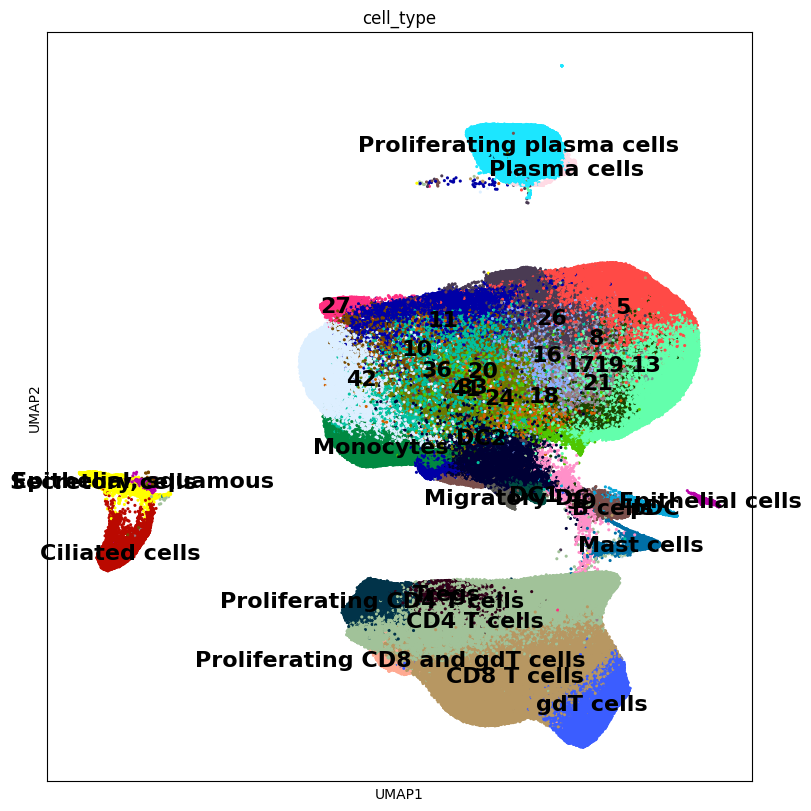

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=20,
    ax=ax,
    show=False,
    legend_fontsize=16
)

In [14]:
del cd4

## Rename Epithelial squamous to Hillock KRT13

In [15]:
adata.obs.cell_type.replace({
    "Epithelial, squamous": "Hillock KRT13",
}, inplace=True)

## Name cluster 39: Hematopoietic stem cells

In [16]:
adata.obs.cell_type.replace({
    "39": "Hematopoietic stem cells",
}, inplace=True)

## Rename monocytes cluster
Monocytes > Monocytes-1

42: Monocytes-2 IL1B

In [17]:
adata.obs.cell_type.replace({
    "Monocytes": "Monocytes-1",
    "42": "Monocytes-2 IL1B"
}, inplace=True)

## Recluster DC2

In [18]:
dc2 = adata[adata.obs.cell_type.isin(['DC2'])]

In [19]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(dc2, use_rep="X_scVI")
rsc.tl.umap(dc2, min_dist=0.3)

In [20]:
# neighbors were already computed using scVI
rsc.tl.leiden(dc2, key_added="cell_type", resolution=0.4)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


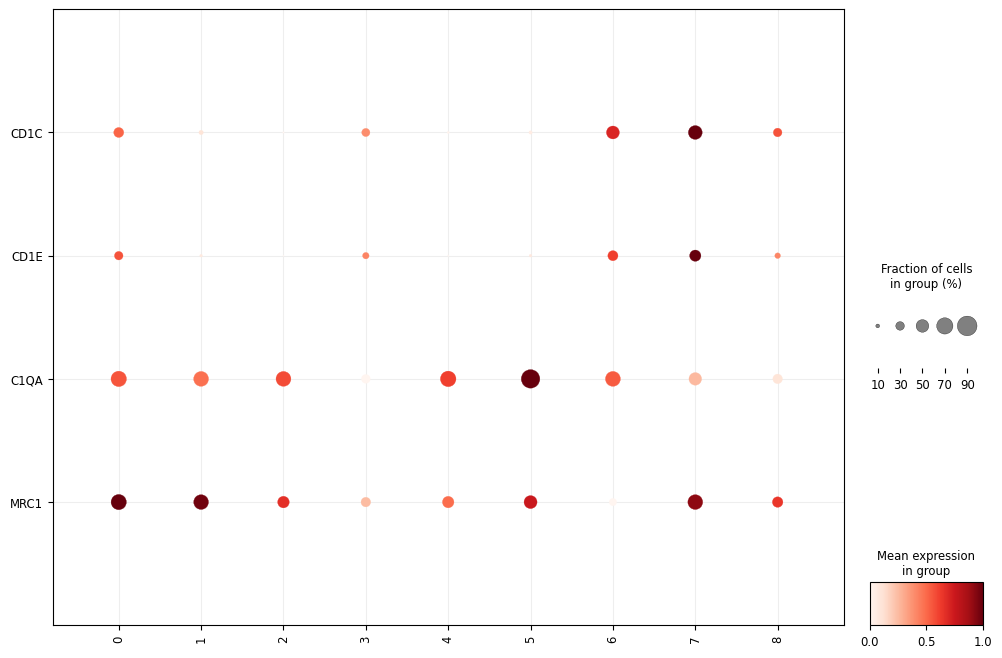

In [21]:
ax = sc.pl.dotplot(
    dc2,
    ["CD1C", "CD1E", "C1QA", "MRC1"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_155743/1293502754.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5'),
 Text(6, 0, '6'),
 Text(7, 0, '7'),
 Text(8, 0, '8')]

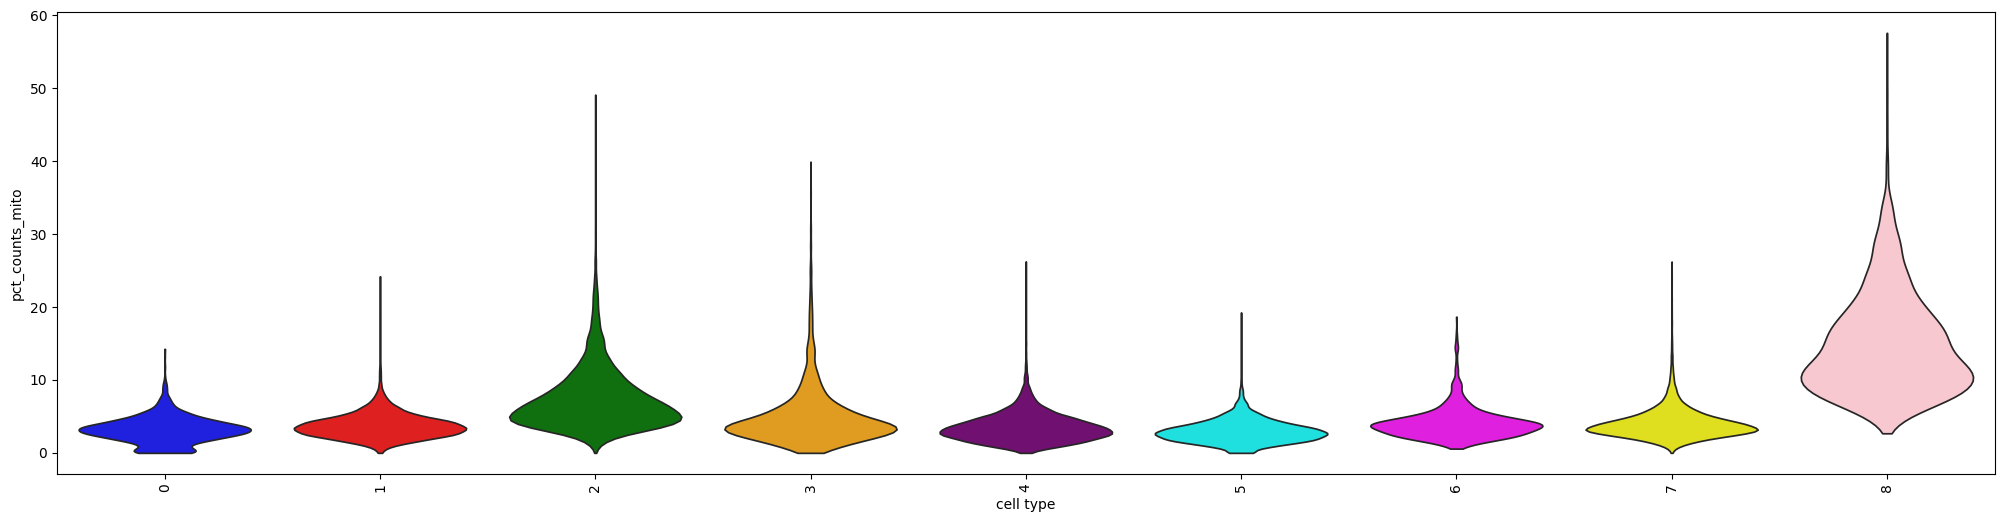

In [22]:
custom_palette = {
    '0': 'blue',
    '1': 'red',
    '2': 'green',
    '3': 'orange',
    '4': 'purple',
    '5': 'cyan',
    '6': 'magenta',
    '7': 'yellow',
    '8': 'pink'
}

# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(dc2, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_155743/1593528032.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5'),
 Text(6, 0, '6'),
 Text(7, 0, '7'),
 Text(8, 0, '8')]

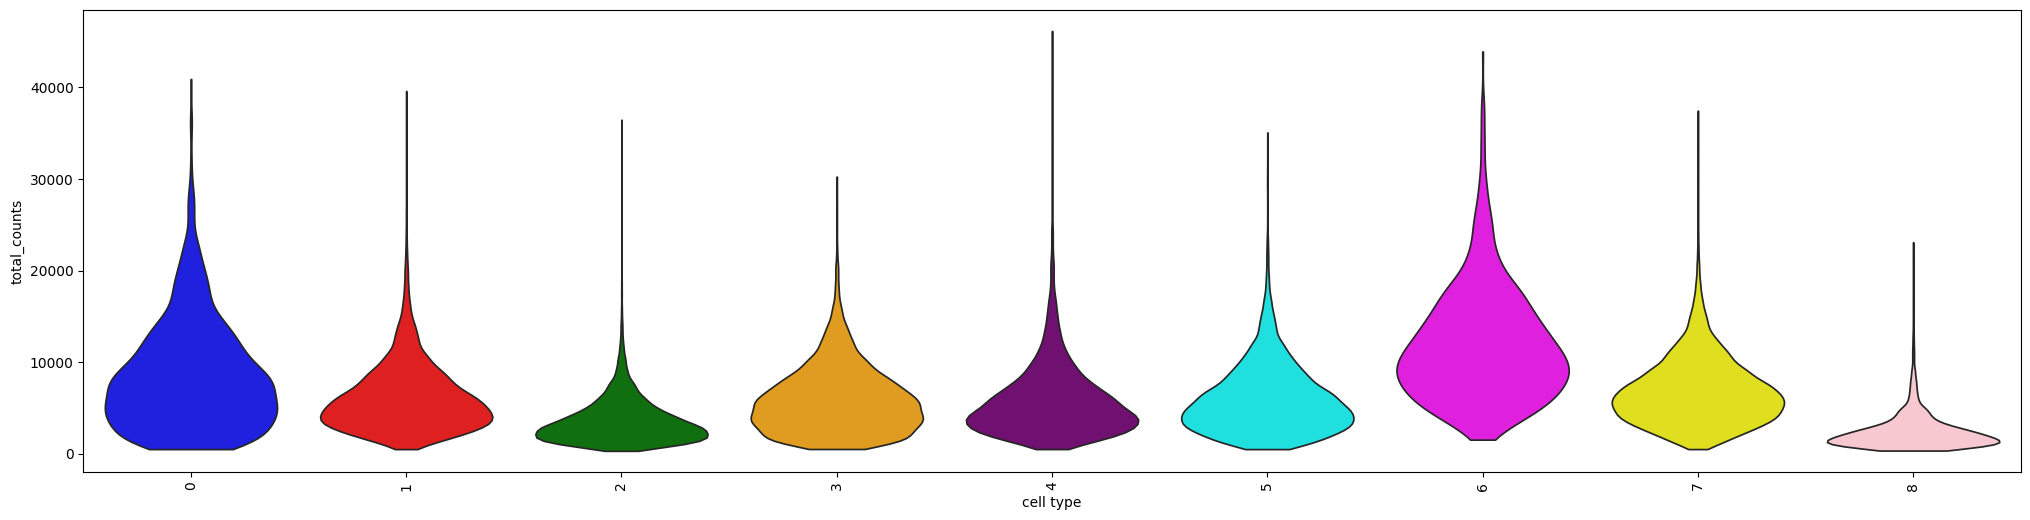

In [23]:
# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(dc2, "total_counts", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

## Remove subcluster 8 - low quality

In [24]:
dc2.obs.cell_type.replace({
    "0": "DC2",
    "1": "Macrophages",
    "2": "Macrophages",
    "3": "DC2",
    "4": "Macrophages",
    "5": "Macrophages",
    "6": "DC2",
    "7": "DC2",
    "8": "remove",
}, inplace=True)

## Merge clusters 5, 8, 13, 19, 21

In [25]:
adata.obs.cell_type.replace({
    "5": "TRAM-1 FABP4",
    "8": "TRAM-1 FABP4",
    "13": "TRAM-1 FABP4",
    "19": "TRAM-1 FABP4",
    "21": "TRAM-1 FABP4",
}, inplace=True)

## Merge clusters 24, 33

In [26]:
adata.obs.cell_type.replace({
    "24": "MoAM-1",
    "33": "MoAM-1",
}, inplace=True)

## Rename cluster 10

In [27]:
adata.obs.cell_type.replace({
    "10": "MoAM-2",
}, inplace=True)

## Rename cluster 36

In [28]:
adata.obs.cell_type.replace({
    "36": "MoAM-3",
}, inplace=True)

## Rename cluster 18

In [29]:
adata.obs.cell_type.replace({
    "18": "MoAM-4",
}, inplace=True)

## Rename cluster 41

In [30]:
adata.obs.cell_type.replace({
    "41": "MoAM-5",
}, inplace=True)

## Rename cluster 16
Double check with Sasha - we skipped this cluster during discussion.

In [31]:
adata.obs.cell_type.replace({
    "16": "TRAM-3 FABP4",
}, inplace=True)

## Recluster 26 - resolve proliferating from rest

In [32]:
cluster26 = adata[adata.obs.cell_type.isin(['26'])]

In [33]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster26, use_rep="X_scVI")
rsc.tl.umap(cluster26, min_dist=0.3)

In [34]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster26, key_added="cell_type", resolution=0.3)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


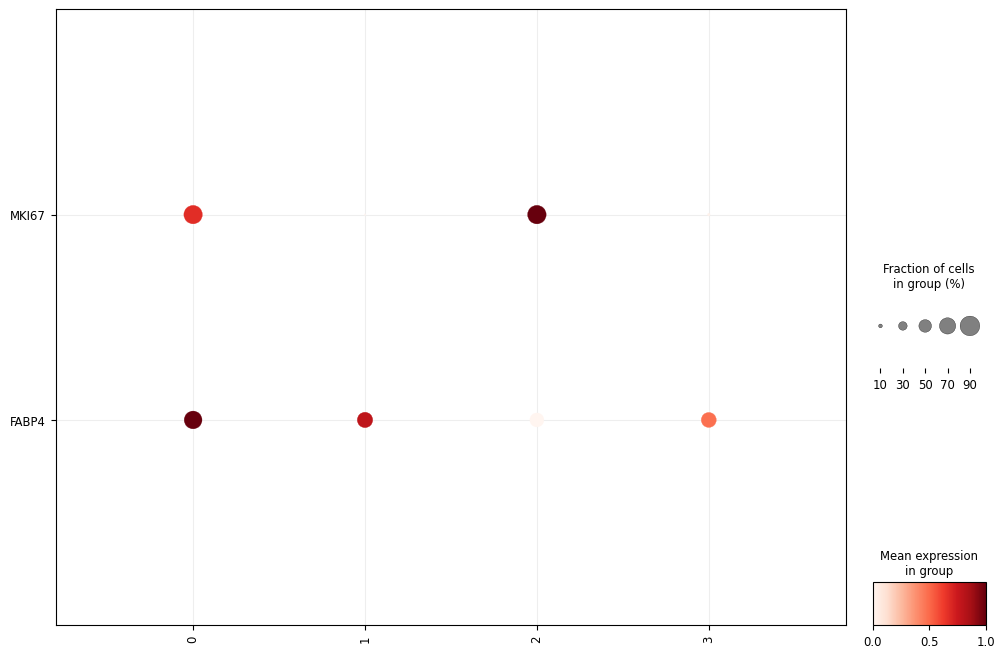

In [35]:
ax = sc.pl.dotplot(
    cluster26,
    ["MKI67", "FABP4"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [36]:
cluster26.obs.cell_type.replace({
    "0": "Proliferating macrophages",
    "1": "TRAM-2 FABP4",
    "2": "Proliferating macrophages",
    "3": "TRAM-2 FABP4",
}, inplace=True)

## Resolve cluster 20
FABP4+, FABP4-, SELENOP+?

In [37]:
cluster20 = adata[adata.obs.cell_type.isin(['20'])]

In [38]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster20, use_rep="X_scVI")
rsc.tl.umap(cluster20, min_dist=0.3)

In [39]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster20, key_added="cell_type", resolution=0.2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


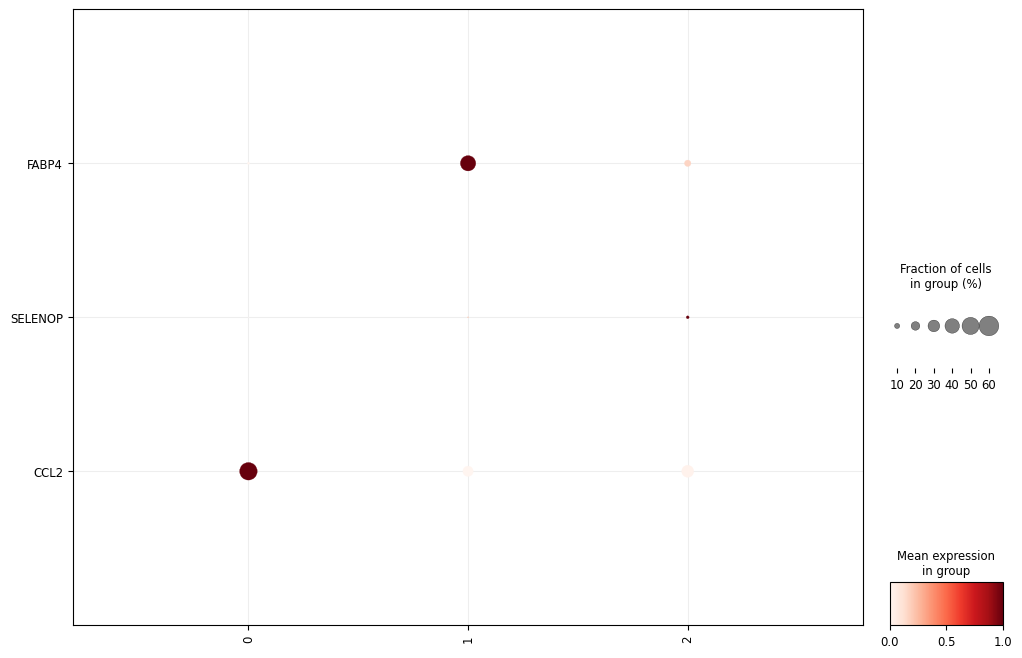

In [40]:
ax = sc.pl.dotplot(
    cluster20,
    ["FABP4", "SELENOP", "CCL2"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [41]:
cluster20.obs.cell_type.replace({
    "0": "MoAM-6",
    "1": "TRAM-3 FABP4",
    "2": "20idk",
}, inplace=True)

## Recluster 11 - Resolve SELENOP+ perivascular macs & low quality

In [42]:
cluster11 = adata[adata.obs.cell_type.isin(['11'])]

In [43]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster11, use_rep="X_scVI")
rsc.tl.umap(cluster11, min_dist=0.3)

In [44]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster11, key_added="cell_type", resolution=0.25)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


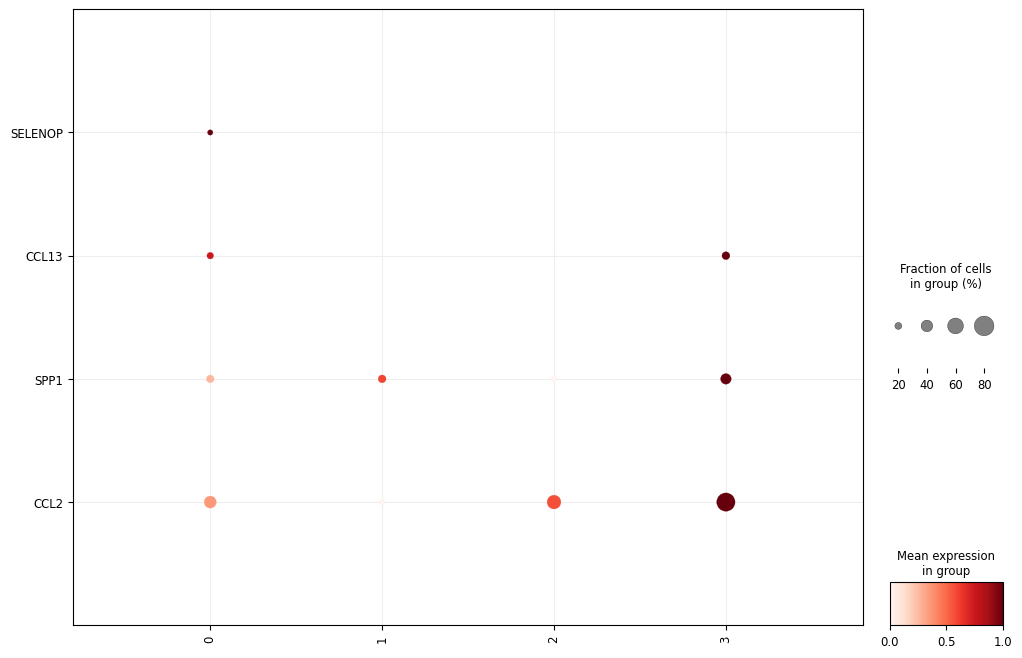

In [45]:
ax = sc.pl.dotplot(
    cluster11,
    ["SELENOP", "CCL13", "SPP1", "CCL2"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_155743/4087546109.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')]

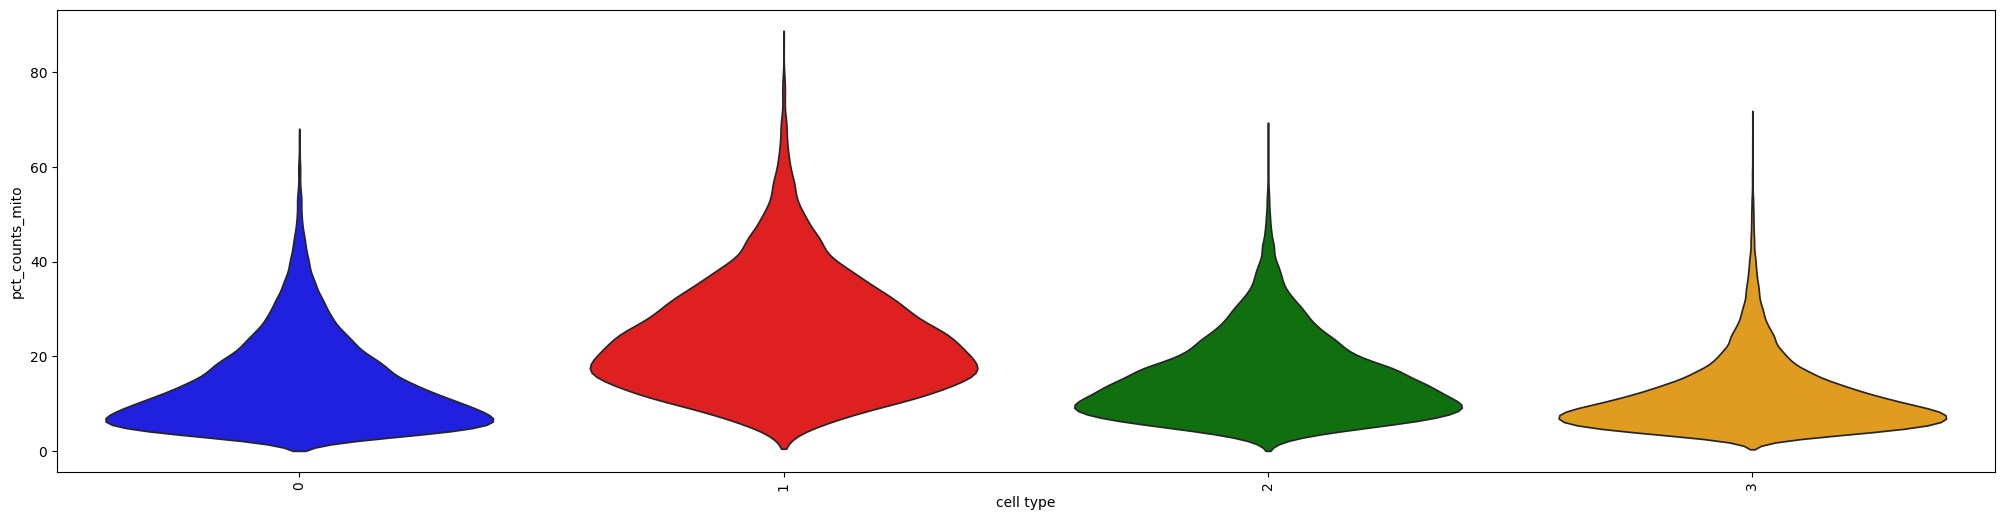

In [46]:
custom_palette = {
    '0': 'blue',
    '1': 'red',
    '2': 'green',
    '3': 'orange',
}

# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(cluster11, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_155743/569459001.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')]

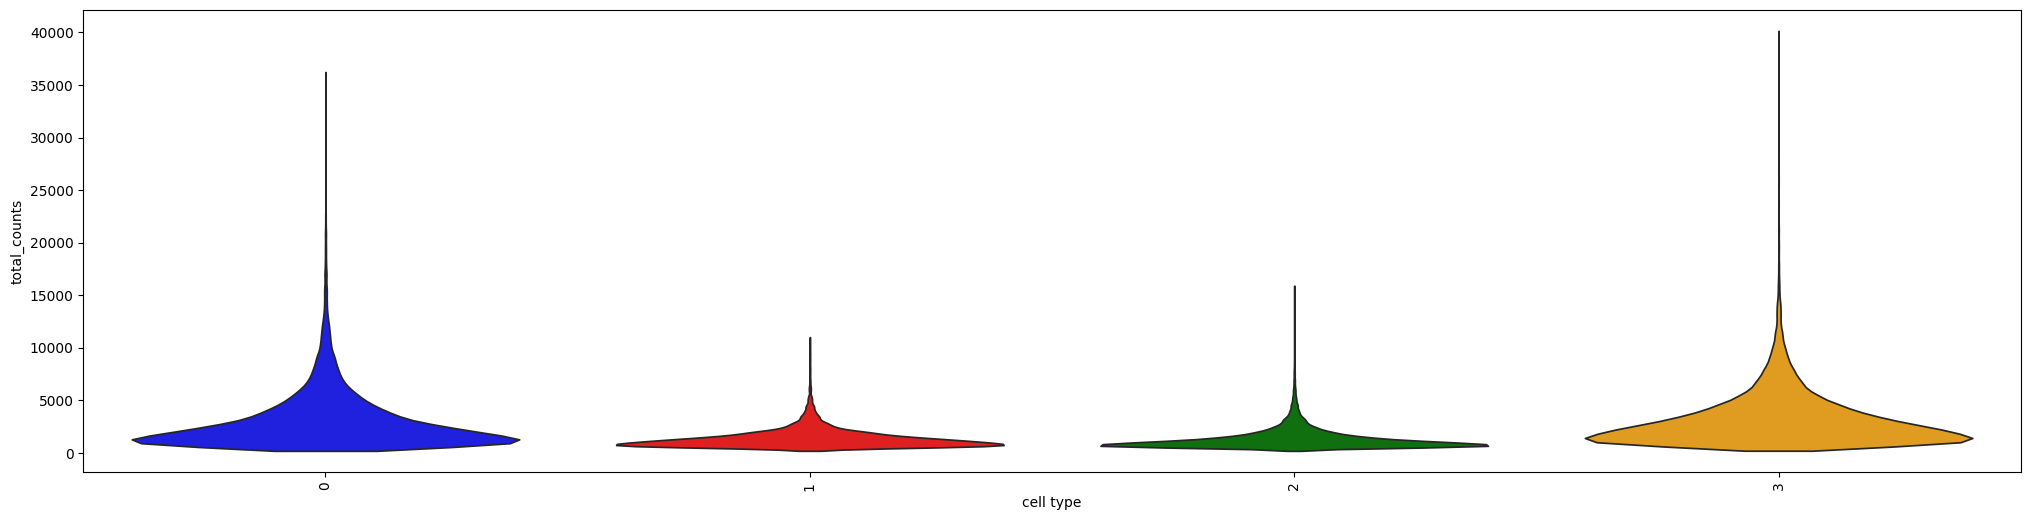

In [47]:
# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(cluster11, "total_counts", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

In [48]:
cluster11.obs.cell_type.replace({
    "0": "Perivascular macrophages",
    "1": "11MoAMidk",
    "2": "MoAM-6",
    "3": "MoAM-7",
}, inplace=True)

### Add subclusters back into large object

In [49]:
adata.obs.cell_type = adata.obs.cell_type.astype("str")

In [50]:
adata.obs.loc[epithelial.obs_names, "cell_type"] = epithelial.obs.cell_type

In [51]:
adata.obs.loc[dc2.obs_names, "cell_type"] = dc2.obs.cell_type

In [52]:
adata.obs.loc[cluster26.obs_names, "cell_type"] = cluster26.obs.cell_type

In [53]:
adata.obs.loc[cluster20.obs_names, "cell_type"] = cluster20.obs.cell_type

In [54]:
adata.obs.loc[cluster11.obs_names, "cell_type"] = cluster11.obs.cell_type

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

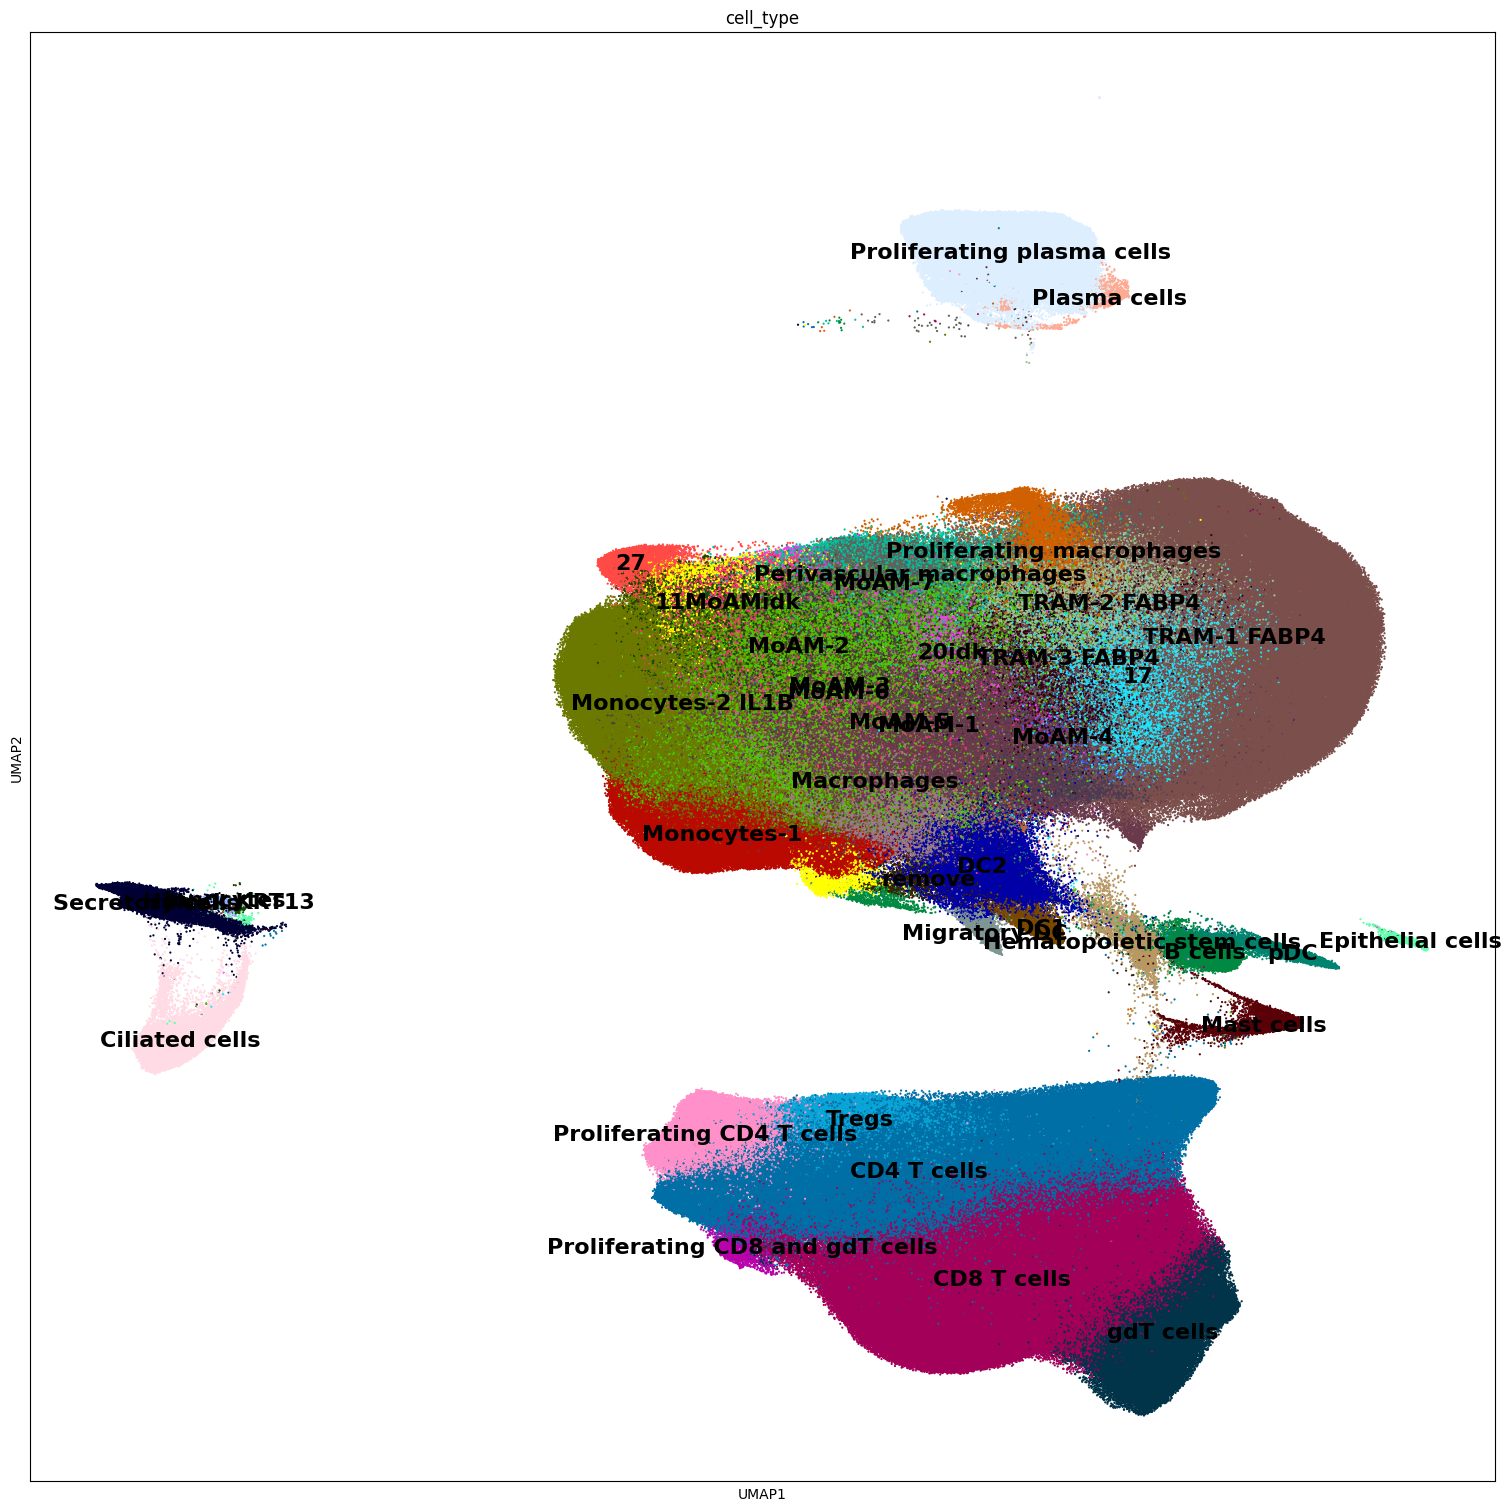

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=10,
    ax=ax,
    show=False,
    legend_fontsize=16
)

## Save

In [ ]:
adata.write(common_data._sc_root / 'scratch/07c_1000_10-2-3.h5ad')

## Read in object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / 'scratch/07c_1000_10-2-3.h5ad')

## Remove Hillock KRT13 - 1 cell

In [3]:
adata = adata[~adata.obs.cell_type.isin(["Hillock KRT13"])]

## Remove cluster 27

In [4]:
adata = adata[~adata.obs.cell_type.isin(['27'])]

## Save

In [ ]:
adata.write(common_data._sc_root / 'scratch/07c_1000_10-2-4.h5ad')

## Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / 'scratch/07c_1000_10-2-4.h5ad')

In [3]:
adata.obs.cell_type.unique().tolist()

['CD4 T cells',
 'CD8 T cells',
 'Mast cells',
 'TRAM-1 FABP4',
 'B cells',
 'MoAM-1',
 'DC2',
 'Macrophages',
 'TRAM-3 FABP4',
 'MoAM-3',
 'Proliferating CD4 T cells',
 '20idk',
 'MoAM-2',
 'Monocytes-2 IL1B',
 'Secretory cells',
 'Proliferating macrophages',
 'Tregs',
 'MoAM-7',
 '17',
 'MoAM-6',
 'MoAM-5',
 'DC1',
 '11MoAMidk',
 'Ionocytes',
 'Ciliated cells',
 'TRAM-2 FABP4',
 'gdT cells',
 'Migratory DC',
 'Perivascular macrophages',
 'Hematopoietic stem cells',
 'Monocytes-1',
 'MoAM-4',
 'pDC',
 'Epithelial cells',
 'Proliferating plasma cells',
 'remove',
 'Proliferating CD8 and gdT cells',
 'Plasma cells']

## Resolve 11MoAMidk into low quality and other

In [4]:
cluster11 = adata[adata.obs.cell_type.isin(['11MoAMidk'])]

In [5]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster11, use_rep="X_scVI")
rsc.tl.umap(cluster11, min_dist=0.3)

In [6]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster11, key_added="cell_type", resolution=0.1)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_156999/4087546109.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1')]

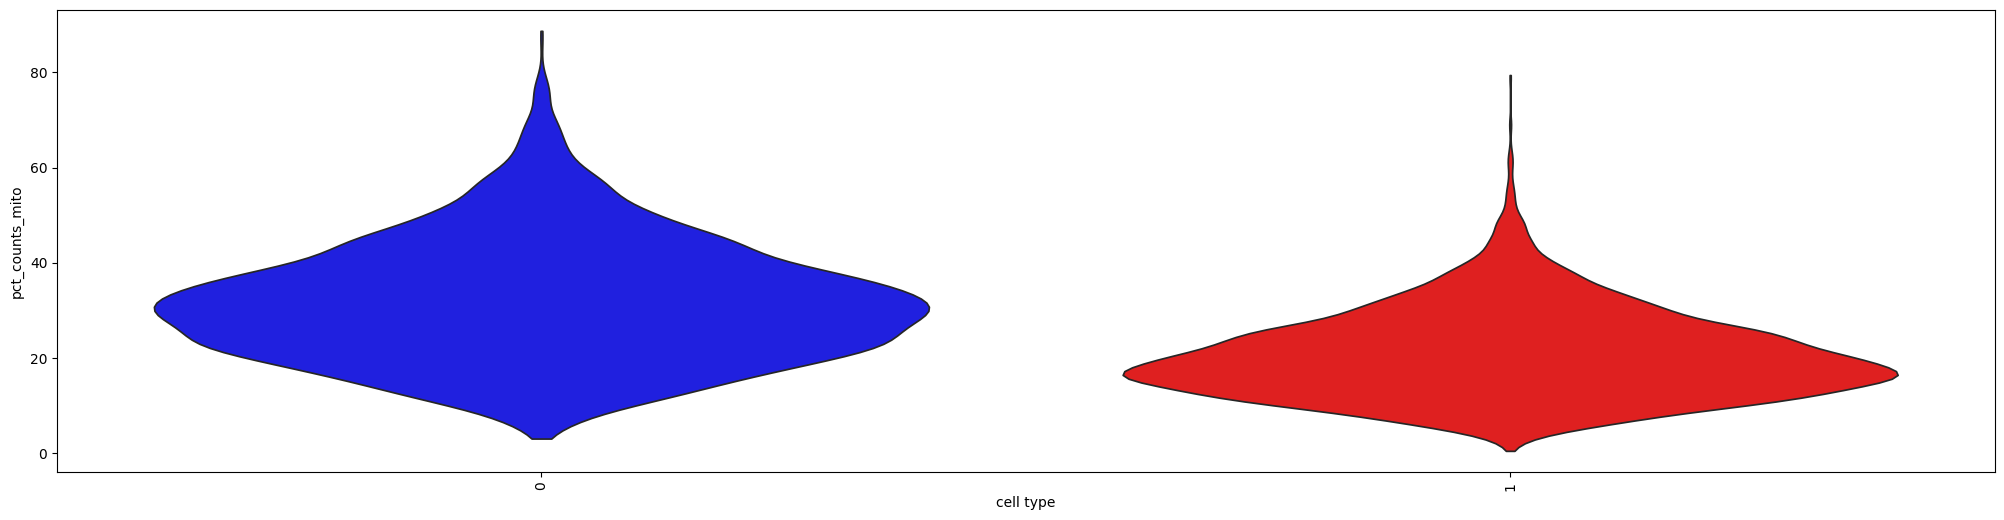

In [7]:
custom_palette = {
    '0': 'blue',
    '1': 'red',
    '2': 'green',
    '3': 'orange',
}

# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(cluster11, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_156999/569459001.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1')]

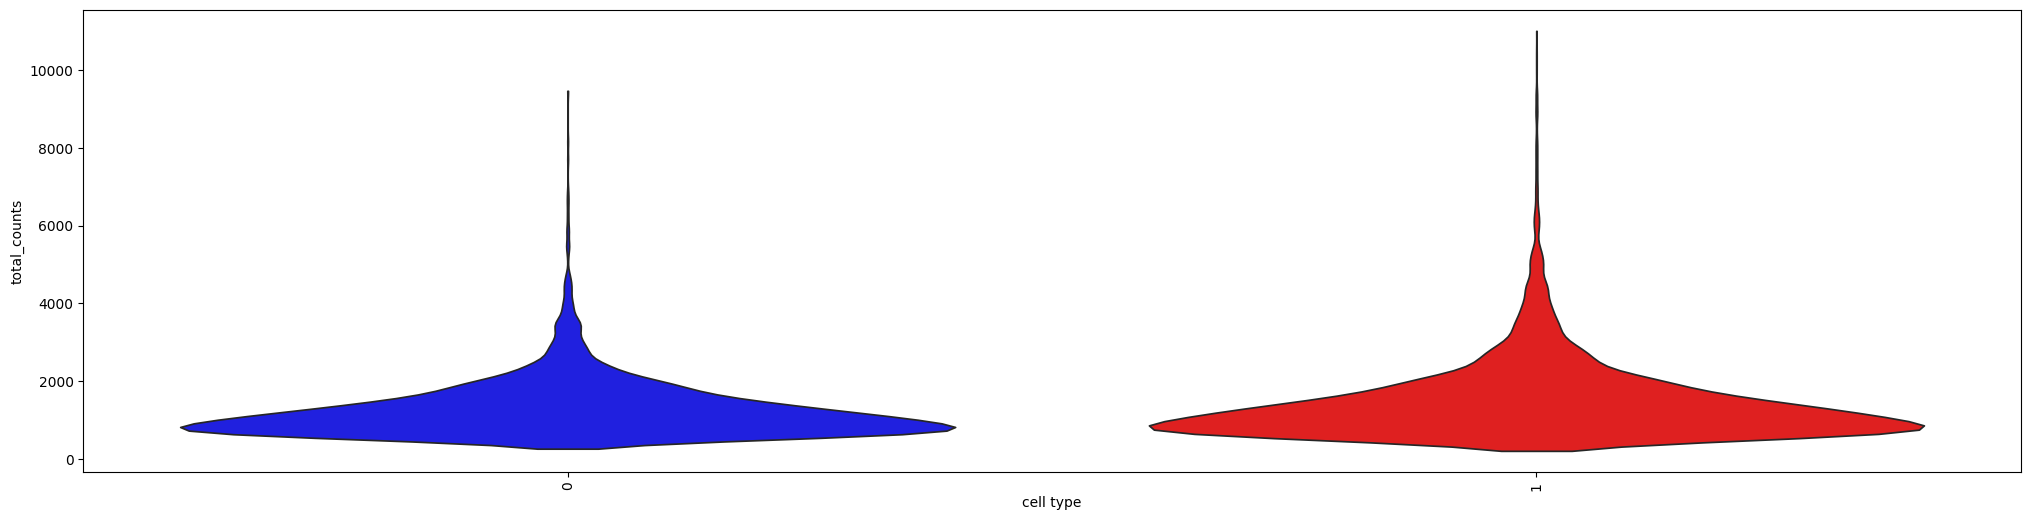

In [8]:
# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(cluster11, "total_counts", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

## Find markers between the two subclusters

In [9]:
%%time
sc.tl.rank_genes_groups(cluster11, "cell_type", method="t-test", n_genes=50)

CPU times: user 188 ms, sys: 11.7 ms, total: 200 ms
Wall time: 199 ms


In [10]:
markers = sc_utils.get_markers(cluster11, "cell_type")

In [11]:
# markers.cluster = markers.cluster.astype(int)
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

In [12]:
markers.groupby("cluster").head(50)

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
18,4.902802e-68,5.882895,0.095378,0.001905,4.902802e-68,0,CLNK
21,5.420151e-61,5.018075,0.088902,0.003370,5.420151e-61,0,GNAO1
35,1.410967e-48,4.075097,0.079188,0.006008,1.410967e-48,0,CCL17
25,2.037769e-53,4.015337,0.085958,0.007327,2.037769e-53,0,CD1C
29,9.629944e-52,3.492833,0.089196,0.009525,9.629944e-52,0,CCR6
...,...,...,...,...,...,...,...
87,7.174642e-203,1.869183,0.529894,0.257286,7.174642e-203,1,CD44
69,1.604054e-281,1.830918,0.963365,0.809538,1.604054e-281,1,SAT1
94,8.643481e-179,1.823865,0.497948,0.230497,8.643481e-179,1,GK
95,3.523167e-178,1.773881,0.538247,0.262879,3.523167e-178,1,SGK1


In [13]:
markers.to_csv('11MoAMidk-markers.csv')

### Remove cluster 0 - low quality

In [14]:
cluster11.obs.cell_type.replace({
    "0": "remove",
    "1": "SPP1 MoAM",
}, inplace=True)

## Recluster B cells - remove low quality

In [15]:
bcells = adata[adata.obs.cell_type.isin(['B cells'])]

In [16]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(bcells, use_rep="X_scVI")
rsc.tl.umap(bcells, min_dist=0.3)

In [17]:
# neighbors were already computed using scVI
rsc.tl.leiden(bcells, key_added="cell_type", resolution=0.1)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_156999/920716557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1')]

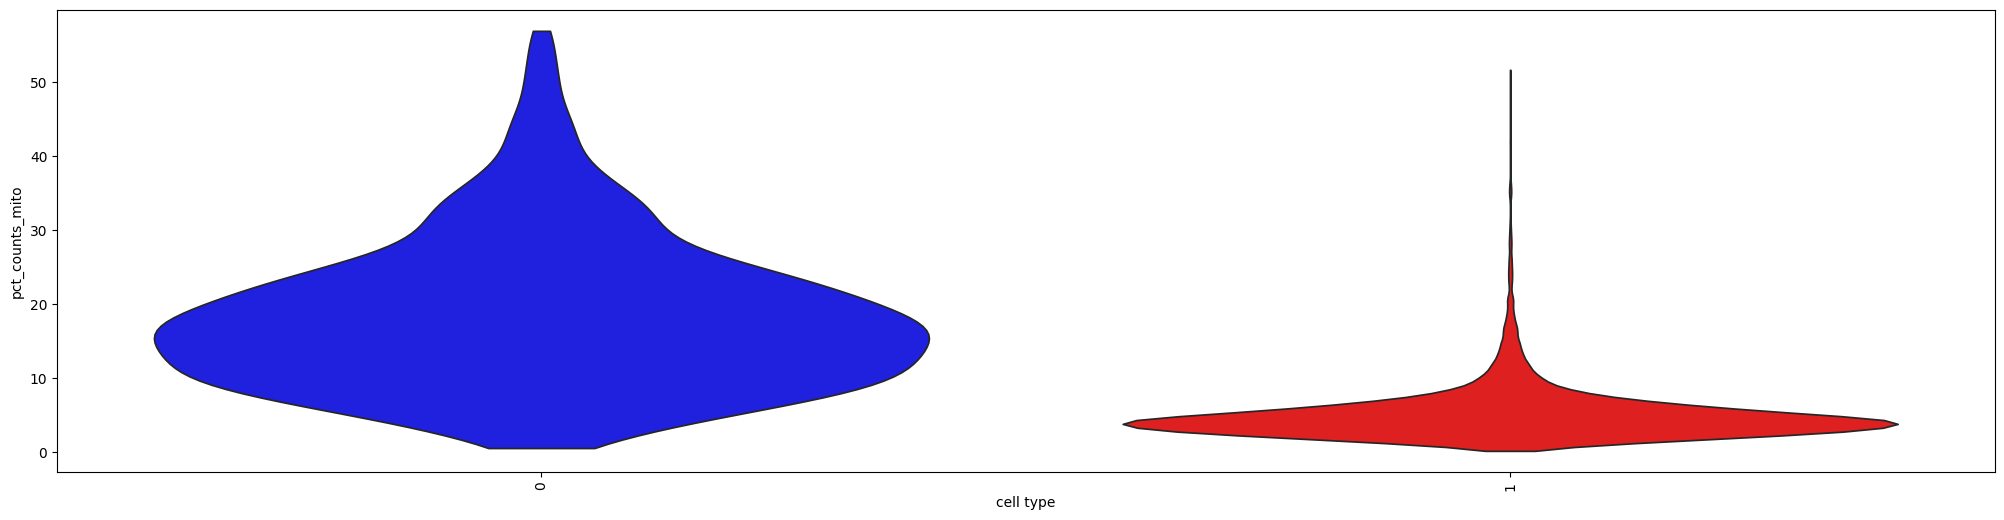

In [18]:
custom_palette = {
    '0': 'blue',
    '1': 'red',
    '2': 'green',
    '3': 'orange',
}

# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(bcells, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_156999/2111411899.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)


[Text(0, 0, '0'), Text(1, 0, '1')]

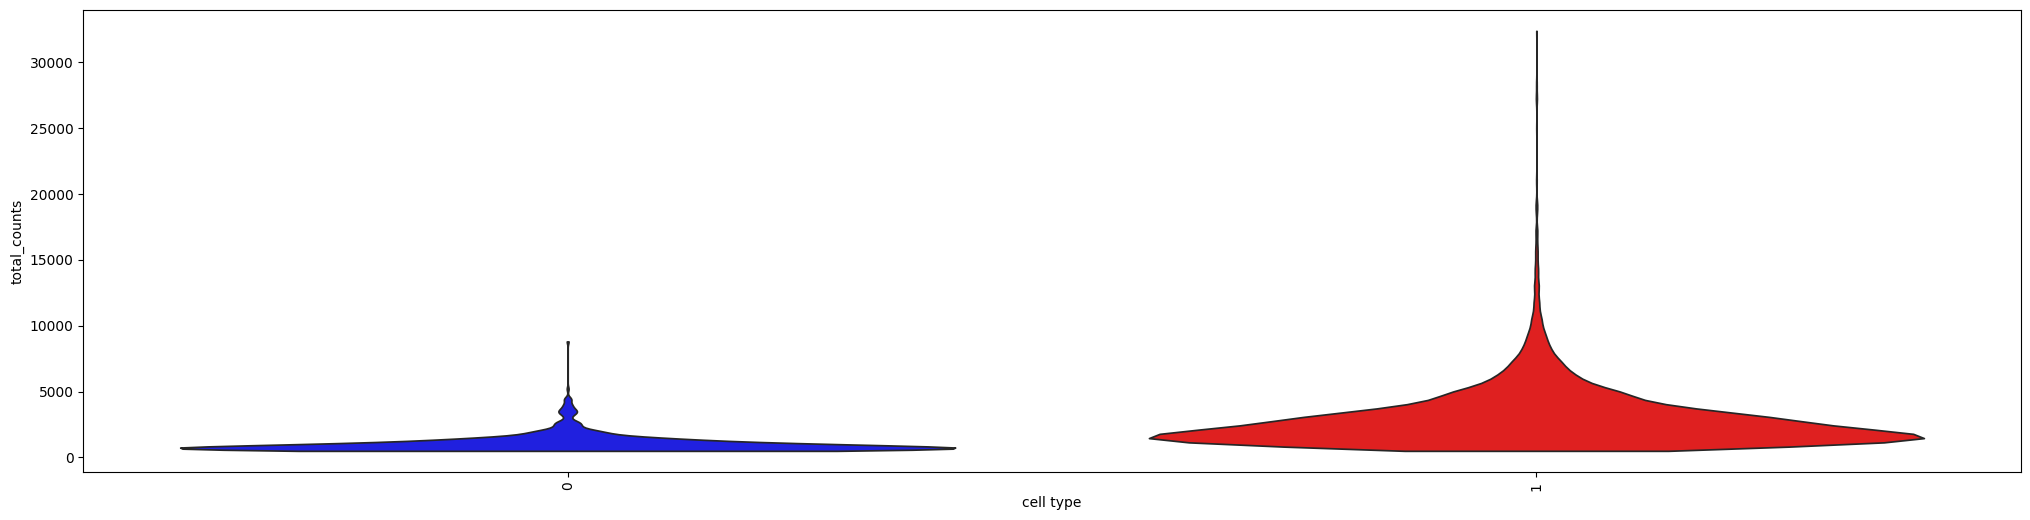

In [19]:
# Create the violin plot with the custom color palette
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(bcells, "total_counts", groupby="cell_type", size=0, ax=ax, show=False, palette=custom_palette)

# Adjust the tick label size and rotation
ax.set_xticklabels(ax.get_xticklabels(), size=10, rotation=90)

### Remove cluster 0 - low quality

In [20]:
bcells.obs.cell_type.replace({
    "0": "remove",
    "1": "B cells",
}, inplace=True)

## Add new cluster labels into large adata object

In [21]:
adata.obs.cell_type = adata.obs.cell_type.astype("str")

In [22]:
adata.obs.loc[cluster11.obs_names, "cell_type"] = cluster11.obs.cell_type

In [23]:
adata.obs.loc[bcells.obs_names, "cell_type"] = bcells.obs.cell_type

## Rename more clusters

In [24]:
adata.obs.cell_type.replace({
    "17": "TRAM-4 FABP4",
    "20idk": "MoAM-8",
}, inplace=True)

### Remove low quality clusters

In [25]:
adata = adata[~adata.obs.cell_type.isin(['remove'])]

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

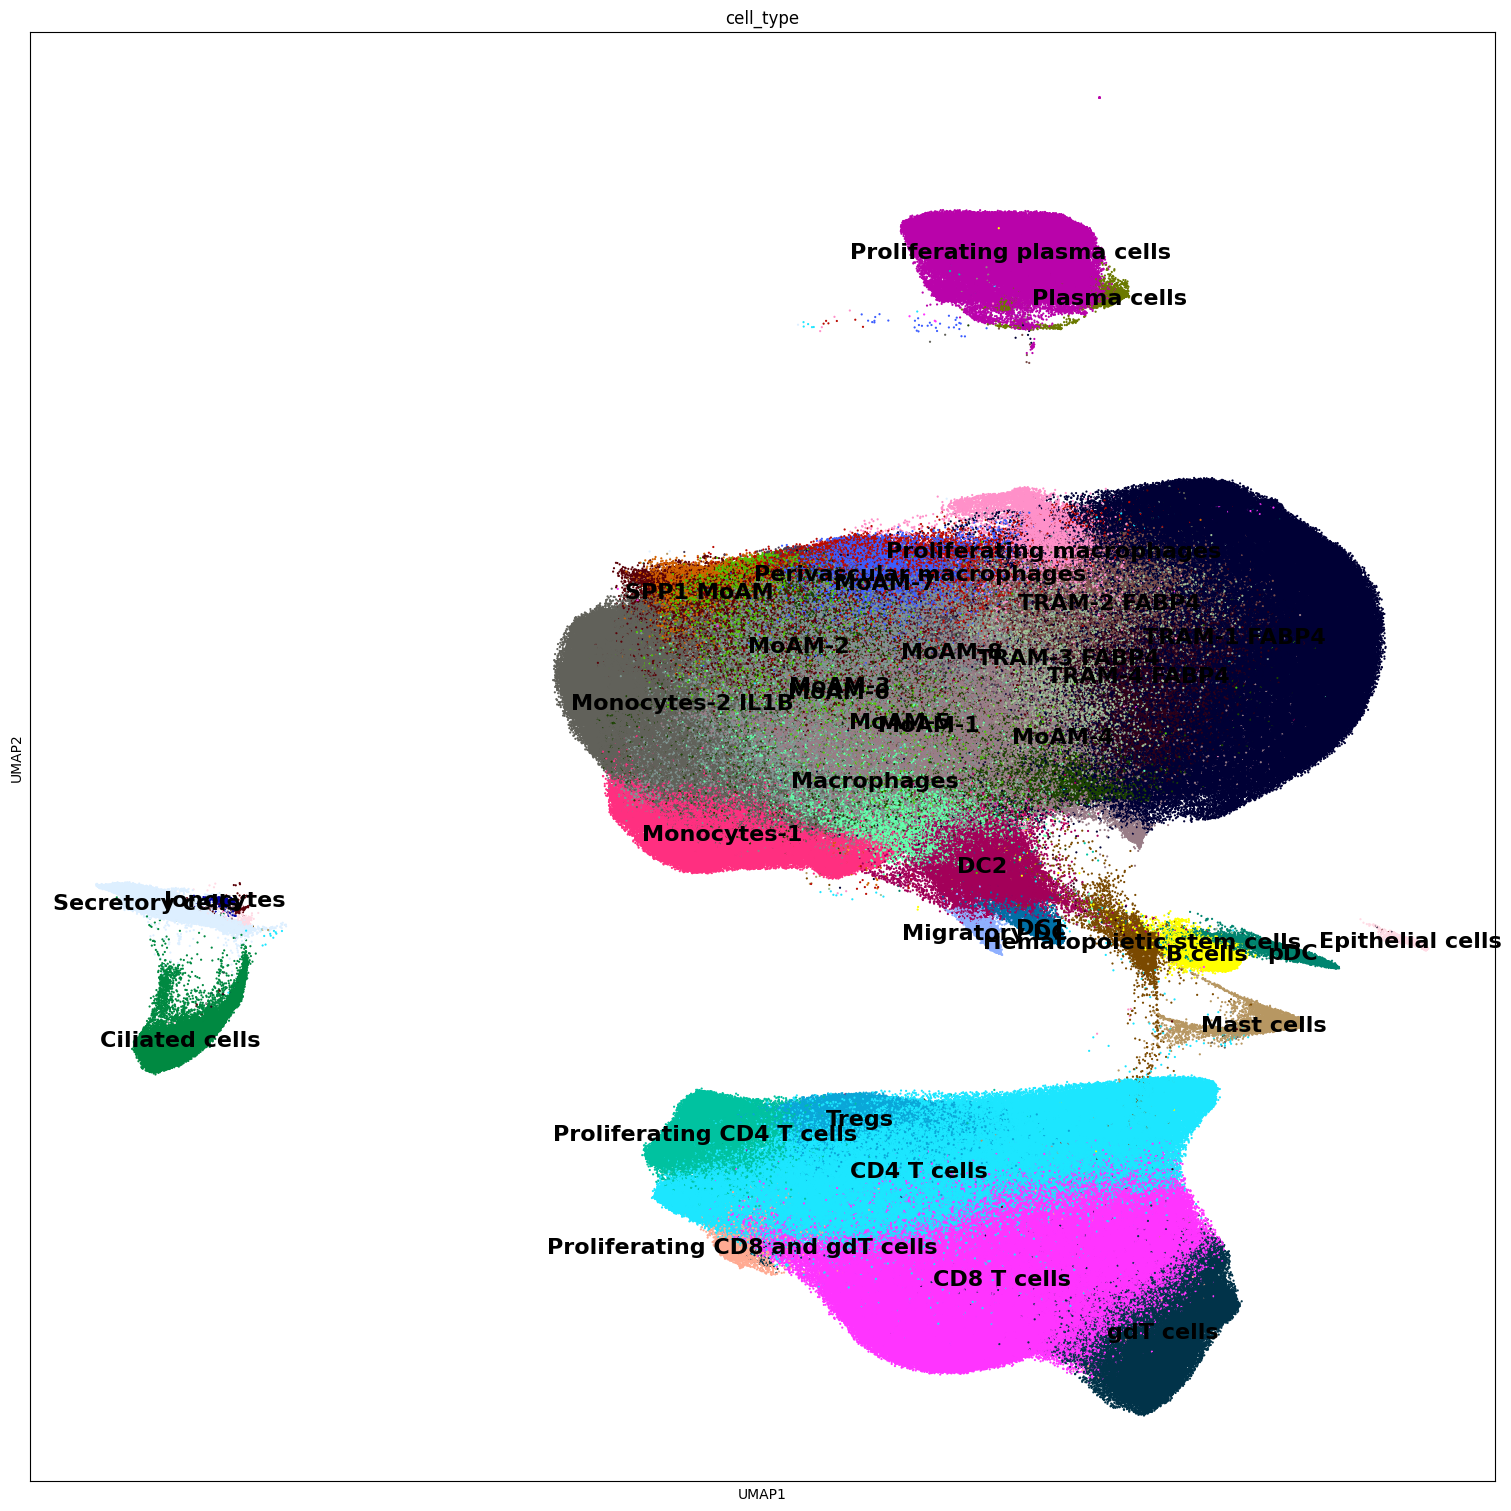

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=10,
    ax=ax,
    show=False,
    legend_fontsize=16
)

## Save

In [ ]:
adata.write(common_data._sc_root / 'scratch/07c_1000_10-2-5.h5ad')

## Generate cluster tree
Pearson correlation plot between clusters using log normalized gene expression data from PCA representation

In [30]:
sc.tl.dendrogram(adata, 'cell_type', cor_method='pearson')

         Falling back to preprocessing with `sc.pp.pca` and default params.


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


<Axes: >

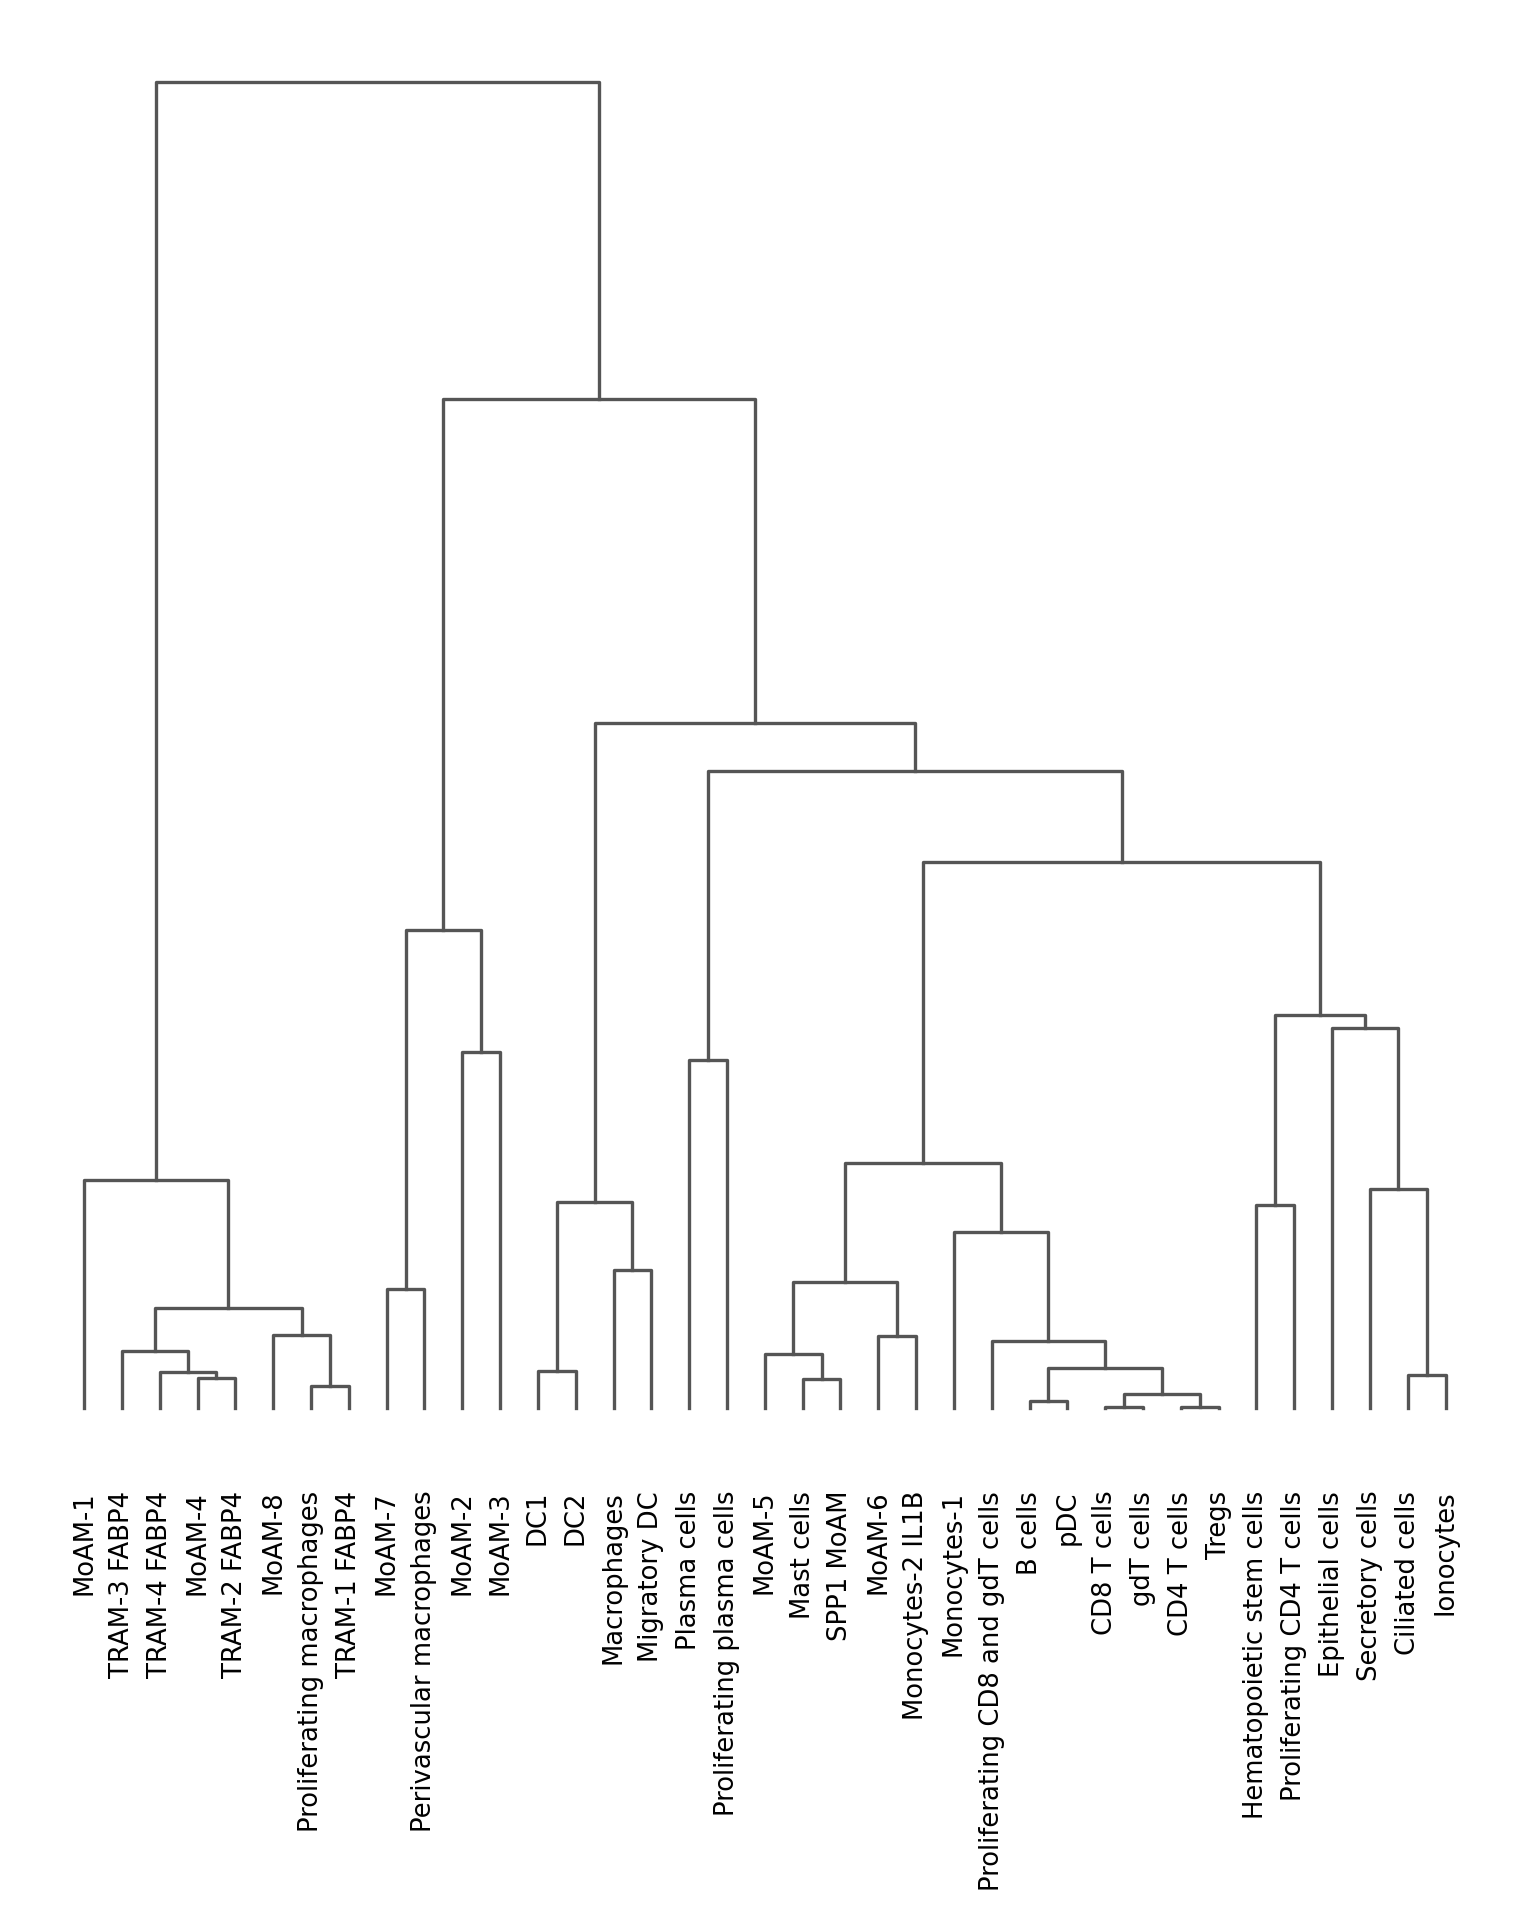

In [31]:
sc.set_figure_params(figsize=(12, 12))
sc.pl.dendrogram(adata, groupby='cell_type', show=False)

## Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / 'scratch/07c_1000_10-2-5.h5ad')

In [3]:
adata.shape

(2454212, 1000)

## Correct metadata - remove cells mapping to two samples
Library SC168 comes from 2 samples (Pt0F61, Pt1K05) and we have a csv file to separate cells into singlets from one patient, singlets from another, doublets, and uncertain. Remove doublets and uncertain cells.

In [ ]:
cells_to_pt = pd.read_csv(
    common_data._sc_root / '11patient_erratum.csv',
    header=None,
    index_col=0,
    names=['patient']
)

In [ ]:
cells_to_pt['sample'] = cells_to_pt.patient.replace({
    'A': 'Pt0F61_S1',
    'B': 'Pt1K05_S1'
})

In [ ]:
cells_to_pt['patient_id'] = cells_to_pt.patient.replace({
    'A': 'Pt0F61',
    'B': 'Pt1K05'
})

In [ ]:
cells_to_pt.index = 'SC168_' + cells_to_pt.index.str.replace('-\d+$', '', regex=True)

In [9]:
cells_to_pt.index.isin(adata.obs_names).sum()

8125

We have 10k cells unambigously mapped to patients by genotype. Out of them 7k are in the data. Additionally, 1k is in the data, but there is no unambigous mapping to patients. Thus, I remove this 1k cells.

In [ ]:
no_mapping_idx = (
    adata.obs.library_id.eq('SC168')
    & ~adata.obs_names.isin(cells_to_pt.index)
)

In [11]:
no_mapping_idx.sum()

1371

In [ ]:
mapping_idx = (
    adata.obs.library_id.eq('SC168')
    & adata.obs_names.isin(cells_to_pt.index)
)

In [13]:
mapping_idx.sum()

8125

In [16]:
adata.obs.loc[mapping_idx, 'individual'] = cells_to_pt['sample'][adata.obs_names[mapping_idx]]

In [17]:
adata.shape

(2454212, 1000)

In [18]:
adata = adata[~no_mapping_idx, :].copy()

In [19]:
adata.shape

(2452841, 1000)

## Save final object!

In [ ]:
adata.write(common_data._sc_root / '07c_1000_10-3/07c_1000_10-3.h5ad')

In [ ]:
adata.obs.to_csv(common_data._sc_root / '07c_1000_10-3/07c_1000_10-3-metadata.csv')

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07c_1000_10-3/07c_1000_10-3.h5ad')

## Find markers with t-test

In [3]:
%%time
sc.tl.rank_genes_groups(adata, "cell_type", method="t-test", n_genes=50)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

CPU times: user 15min 11s, sys: 7min 58s, total: 23min 9s
Wall time: 23min 10s


In [4]:
markers = sc_utils.get_markers(adata, "cell_type")

In [5]:
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

In [ ]:
markers.to_csv(common_data._sc_root / '07c_1000_10-3/07c_1000_10-3-markers.csv')